In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("fda_ai_device_recalls.csv")

In [3]:
df.head()

,recall_link_id,submission_number,authorization_pathway,device_name,company_name,final_decision_date,primary_product_code,cfres_id,res_event_number,product_res_number,...,product_description,code_info,product_quantity,reason_for_recall,root_cause_description,action,distribution_pattern,linked_submission_field,linkage_method,source_snapshot_date
0,K240465|220683,K240465,510(k),O-arm O2 Imaging System,"Medtronic Navigation, Inc",2024-06-21,OWB,220683,99041,Z-2451-2026,...,Medtronic O-arm O2 Imaging System. Model Numbe...,Model Number: BI70002000. GTIN (Serial Numbers...,589 units,Potential for image artifacts caused by an ano...,Under Investigation by firm,Medtronic notified consignees on about 05/19/2...,Worldwide distribution - US Nationwide and the...,k_numbers,exact_submission_number,2026-07-31
1,K252842|220295,K252842,510(k),SafeOp 3: Neural Informatix System,"Alphatec Spine, Inc.",2026-01-11,GWF,220295,98967,Z-2793-2026,...,"SafeOp Patient Interface, REF: AIX11240, part ...",UDI-DI: 00190376517506.\nSystem Set ID/Patient...,3,"Intraoperative neuromonitoring device, due to ...",Software Design Change,"On 5/13/2026, recall notices were emailed to c...",US Nationwide distribution in the states of TX...,k_numbers,exact_submission_number,2026-07-31
2,K250330|220230,K250330,510(k),3mensio Workstation,Pie Medical Imaging BV,2025-11-03,QIH,220230,98930,Z-2767-2026,...,3mensio Workstation (Vascular Fenestrated) sof...,Software Version 10.7.\nUDIs:\n(01)08056304455...,165,User measurement value reported by diagnostic ...,Software change control,"On 5/7/2026, correction notices were emailed t...",Worldwide - US Nationwide distribution in the ...,k_numbers,exact_submission_number,2026-07-31
3,K213583|219770,K213583,510(k),"Achieva, Ingenia, Ingenia CX, Ingenia Elition ...",Philips Medical Systems Nederland B.V.,2022-05-16,LNH,219770,98779,Z-1954-2026,...,Philips Evolution Upgrade 1.5T with MR Elastog...,1. Model Number (REF): 782116. UDI: (01)008848...,8 units,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31
4,K213583|219859,K213583,510(k),"Achieva, Ingenia, Ingenia CX, Ingenia Elition ...",Philips Medical Systems Nederland B.V.,2022-05-16,LNH,219859,98779,Z-1961-2026,...,Philips Ingenia Ambition X with MR Elastograph...,1. Model Number (REF): 781356. UDI: (01)008848...,86 units,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31


In [4]:
df.shape

(313, 29)

In [5]:
df.describe()

,cfres_id,res_event_number,days_from_authorization_to_recall,recall_after_authorization_flag,firm_fei_number
count,313.000000,313.000000,313.000000,313.000000,3.130000e+02
mean,199836.769968,92031.246006,855.875399,0.984026,1.958722e+09
std,23948.240659,8181.702017,841.354894,0.125577,1.424616e+09
min,52358.000000,37954.000000,-305.000000,0.000000,1.119779e+06
25%,189064.000000,88595.000000,325.000000,1.000000,2.240869e+06
50%,207139.000000,94388.000000,717.000000,1.000000,3.006648e+09
75%,215861.000000,97530.000000,1211.000000,1.000000,3.007774e+09
max,220683.000000,99041.000000,8393.000000,1.000000,3.027339e+09


In [6]:
df.isnull().sum().sort_values(ascending=False)

event_date_created                   242
event_date_terminated                234
product_quantity                      23
code_info                              2
action                                 1
company_name                           0
final_decision_date                    0
cfres_id                               0
primary_product_code                   0
submission_number                      0
authorization_pathway                  0
device_name                            0
recall_link_id                         0
event_date_initiated                   0
recall_status                          0
product_res_number                     0
res_event_number                       0
recalling_firm                         0
firm_fei_number                        0
recall_after_authorization_flag        0
days_from_authorization_to_recall      0
product_description                    0
recall_product_code                    0
reason_for_recall                      0
root_cause_descr

In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
308    False
309    False
310    False
311    False
312    False
Length: 313, dtype: bool

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   recall_link_id                     313 non-null    str  
 1   submission_number                  313 non-null    str  
 2   authorization_pathway              313 non-null    str  
 3   device_name                        313 non-null    str  
 4   company_name                       313 non-null    str  
 5   final_decision_date                313 non-null    str  
 6   primary_product_code               313 non-null    str  
 7   cfres_id                           313 non-null    int64
 8   res_event_number                   313 non-null    int64
 9   product_res_number                 313 non-null    str  
 10  recall_status                      313 non-null    str  
 11  event_date_initiated               313 non-null    str  
 12  event_date_created               

In [9]:
df.describe(include="all")

,recall_link_id,submission_number,authorization_pathway,device_name,company_name,final_decision_date,primary_product_code,cfres_id,res_event_number,product_res_number,...,product_description,code_info,product_quantity,reason_for_recall,root_cause_description,action,distribution_pattern,linked_submission_field,linkage_method,source_snapshot_date
count,313,313,313,313,313,313,313,313.000000,313.000000,313,...,313,311,290,313,313,312,313,313,313,313
unique,313,102,2,92,59,99,28,NaN,NaN,268,...,267,262,198,147,20,146,126,2,1,1
top,K240465|220683,K190387,510(k),RayStation,RaySearch Laboratories AB (publ),2019-06-19,LNH,NaN,NaN,Z-1482-2024,...,RayStation Software Version Numbers version nu...,Version Number (Build Number/UDI): 8B (8.1.0.4...,3 units,The potential for stiffness value errors when ...,Under Investigation by firm,Philips Medical notified consignees on about 0...,Worldwide - US Nationwide and the countries of...,k_numbers,exact_submission_number,2026-07-31
freq,1,32,309,46,72,32,96,NaN,NaN,6,...,6,6,8,25,108,25,25,309,313,313
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,199836.769968,92031.246006,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23948.240659,8181.702017,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52358.000000,37954.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189064.000000,88595.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207139.000000,94388.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215861.000000,97530.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
target = "recall_after_authorization_flag"

In [26]:
df[target].value_counts()

recall_after_authorization_flag
1    308
0      5
Name: count, dtype: int64

In [30]:
df[target].value_counts(normalize=True) * 100

recall_after_authorization_flag
1    98.402556
0     1.597444
Name: proportion, dtype: float64

In [27]:
X = df.drop(columns=[target])
y = df[target]

In [28]:
X.shape

(313, 28)

In [29]:
y.shape

(313,)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1
    ),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
}

In [ ]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

In [37]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
print("Numeric:", list(numeric_features))

Numeric: ['cfres_id', 'res_event_number', 'days_from_authorization_to_recall', 'firm_fei_number']


In [38]:
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns
print("Categorical:", list(categorical_features))

Categorical: ['recall_link_id', 'submission_number', 'authorization_pathway', 'device_name', 'company_name', 'final_decision_date', 'primary_product_code', 'product_res_number', 'recall_status', 'event_date_initiated', 'event_date_created', 'event_date_terminated', 'recalling_firm', 'recall_product_code', 'product_description', 'code_info', 'product_quantity', 'reason_for_recall', 'root_cause_description', 'action', 'distribution_pattern', 'linked_submission_field', 'linkage_method', 'source_snapshot_date']


In [ ]:
numeric_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

In [ ]:
categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
results = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    results.append(
        [
            name,
            scores["test_accuracy"].mean(),
            scores["test_precision"].mean(),
            scores["test_recall"].mean(),
            scores["test_f1"].mean(),
            scores["test_roc_auc"].mean(),
        ]
    )

In [ ]:
results = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)
results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
3,Extra Trees,0.984025,0.984025,1.000000,0.991948,0.761026
2,Random Forest,0.984025,0.984025,1.000000,0.991948,0.987044
0,Logistic Regression,0.977624,0.983920,0.993496,0.988669,0.944527
4,SVM,0.977624,0.983920,0.993496,0.988669,0.947911


In [ ]:
best_model_name = "Random Forest"
best_model = models[best_model_name]
final_pipeline = Pipeline([("prep", preprocessor), ("model", best_model)])
final_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [ ]:
sample = X.iloc[[0]]
prediction = final_pipeline.predict(sample)[0]
probability = final_pipeline.predict_proba(sample)[0][1]
print("Predicted Class:", prediction)
print("Probability of Recall:", f"{probability:.2%}")

Predicted Class: 1
Probability of Recall: 100.00%


In [ ]:
predictions = final_pipeline.predict(X)
probabilities = final_pipeline.predict_proba(X)[:, 1]
prediction_results = pd.DataFrame(
    {"Actual": y.values, "Predicted": predictions, "Recall_Probability": probabilities}
)

In [49]:
prediction_results.head(10)

,Actual,Predicted,Recall_Probability
0,1,1,1.0
1,1,1,1.0
2,1,1,1.0
3,1,1,1.0
4,1,1,1.0
5,1,1,1.0
6,1,1,1.0
7,1,1,1.0
8,1,1,1.0
9,1,1,1.0


In [ ]:
print(classification_report(y, predictions, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00       308

    accuracy                           1.00       313
   macro avg       1.00      1.00      1.00       313
weighted avg       1.00      1.00      1.00       313



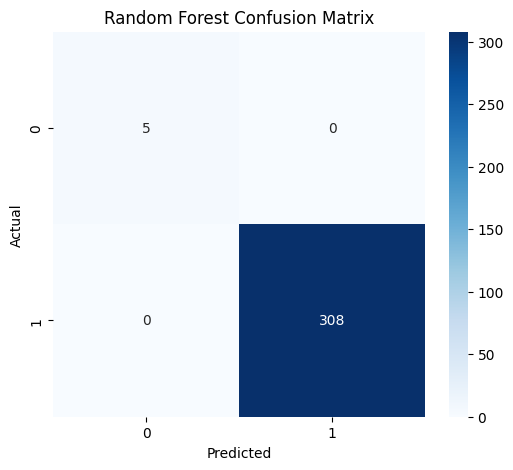

In [ ]:
cm = confusion_matrix(y, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()